In [1]:
import pandas as pd
import numpy as np

In [2]:
#load dataset 
df = pd.read_csv("D:\onedrive\Desktop\CIC DDOS 2017 DATA_SET\Friday-WorkingHours-Morning.pcap_ISCX.csv")

In [3]:
df[' Label'] = df[' Label'].str.strip()

In [4]:
#y = DF[' Label']
#y


#df.isnull().sum()

In [5]:
y = df[' Label']
X = df.drop(' Label', axis= 1)


In [6]:
#X.info()

In [7]:
#X = X.apply(pd.to_numeric, errors='coerce')

df2 = pd.DataFrame()

df2 = np.isinf(X).sum()
df2.to_csv("data_file_1.csv")


In [8]:
l = [np.isnan(X).sum()]
print(l)

[ Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
 Total Backward Packets        0
Total Length of Fwd Packets    0
                              ..
 Active Min                    0
Idle Mean                      0
 Idle Std                      0
 Idle Max                      0
 Idle Min                      0
Length: 78, dtype: int64]


In [9]:
X.replace([np.inf, -np.inf], np.nan, inplace=True)

In [10]:
X.to_csv("data_file_2.csv")

In [11]:
# fills missing values
X['Flow Bytes/s'] = X['Flow Bytes/s'].fillna(X['Flow Bytes/s'].mean())

In [12]:
X[' Flow Packets/s'] = X[' Flow Packets/s'].fillna(X[' Flow Packets/s'].mean())

In [13]:
df2 = pd.DataFrame()

df2 = np.isinf(X).sum()
df2.to_csv("data_file_1.csv")


In [14]:
"""
1: used to check infinite values in dataframe
2: checks NaN values
3: checks null values

"""

np.isinf(X).sum()
np.isnan(X).sum()
X.isnull().sum()

 Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
 Total Backward Packets        0
Total Length of Fwd Packets    0
                              ..
 Active Min                    0
Idle Mean                      0
 Idle Std                      0
 Idle Max                      0
 Idle Min                      0
Length: 78, dtype: int64

In [15]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 191033 entries, 0 to 191032
Series name:  Label
Non-Null Count   Dtype 
--------------   ----- 
191033 non-null  object
dtypes: object(1)
memory usage: 1.5+ MB


In [16]:
y

0         BENIGN
1         BENIGN
2         BENIGN
3         BENIGN
4         BENIGN
           ...  
191028    BENIGN
191029    BENIGN
191030    BENIGN
191031    BENIGN
191032    BENIGN
Name:  Label, Length: 191033, dtype: object

In [17]:
# convert target from string to int 

y = pd.get_dummies(y, columns = [' Label'], drop_first = 1)
y.to_csv("target_data_of_ddos_1.csv")

In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=10000)

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


x_train,  x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state =42)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test,y_pred)
print("accuracy score: ",accuracy)

print("classification report: \n",classification_report(y_test, y_pred))


C:\Users\91997\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


accuracy score:  0.9947391839191772
classification report: 
               precision    recall  f1-score   support

       False       1.00      1.00      1.00     37833
        True       0.91      0.51      0.66       374

    accuracy                           0.99     38207
   macro avg       0.95      0.76      0.83     38207
weighted avg       0.99      0.99      0.99     38207



C:\Users\91997\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


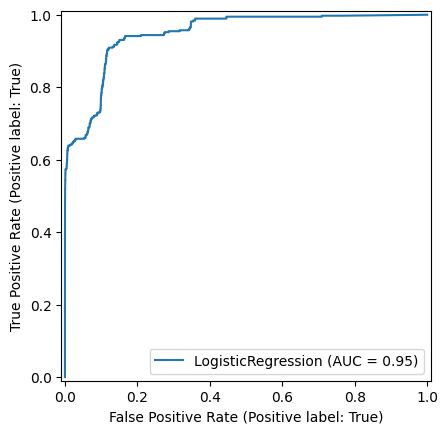

In [20]:
import matplotlib.pyplot as plt

from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(model, x_test, y_test)

plt.show()